In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import scipy as sp
from scipy import ndimage
from shutil import copyfile
from tensorflow.keras.layers import Conv2D, Add, MaxPooling2D, Dense, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator

I0000 00:00:1775486143.701886    4712 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775486144.468695    4712 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775486146.129766    4712 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
!pip install -q kaggle

In [3]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/home/kaming/.kaggle’: File exists


In [4]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
microsoft-catsvsdogs-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
!unzip -o microsoft-catsvsdogs-dataset.zip 

Archive:  microsoft-catsvsdogs-dataset.zip
  inflating: MSR-LA - 3467.docx      
  inflating: PetImages/Cat/0.jpg     
  inflating: PetImages/Cat/1.jpg     
  inflating: PetImages/Cat/10.jpg    
  inflating: PetImages/Cat/100.jpg   
  inflating: PetImages/Cat/1000.jpg  
  inflating: PetImages/Cat/10000.jpg  
  inflating: PetImages/Cat/10001.jpg  
  inflating: PetImages/Cat/10002.jpg  
  inflating: PetImages/Cat/10003.jpg  
  inflating: PetImages/Cat/10004.jpg  
  inflating: PetImages/Cat/10005.jpg  
  inflating: PetImages/Cat/10006.jpg  
  inflating: PetImages/Cat/10007.jpg  
  inflating: PetImages/Cat/10008.jpg  
  inflating: PetImages/Cat/10009.jpg  
  inflating: PetImages/Cat/1001.jpg  
  inflating: PetImages/Cat/10010.jpg  
  inflating: PetImages/Cat/10011.jpg  
  inflating: PetImages/Cat/10012.jpg  
  inflating: PetImages/Cat/10013.jpg  
  inflating: PetImages/Cat/10014.jpg  
  inflating: PetImages/Cat/10015.jpg  
  inflating: PetImages/Cat/10016.jpg  
  inflating: PetImages/Cat/1

In [6]:
class_names = ['Cat', 'Dog']

cat_dir = './PetImages/Cat'
dog_dir = './PetImages/Dog'
n_cats = len(os.listdir(cat_dir))
n_dogs = len(os.listdir(dog_dir))
n_images = [n_cats, n_dogs]
px.pie(names=class_names, values=n_images)

In [7]:
#Buat Struktur direktor
try:
  base_dir = './cats-v-dogs'
  folders = [
      'training/cats',
      'training/dogs',
      'validation/cats',
      'validation/dogs',
      'test/cats',
      'test/dogs'
  ]

  for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)
  print('Direktori berhasil dibuat.')
except OSError:
  print('Error: Gagal membuat direktori.')


Direktori berhasil dibuat.


In [8]:
os.listdir('./cats-v-dogs')

['test', 'training', 'validation']

In [9]:
#Define data path
CAT_DIR = './PetImages/Cat'
DOG_DIR = './PetImages/Dog'

TRAINING_CATS = './cats-v-dogs/training/cats'
TRAINING_DOGS = './cats-v-dogs/training/dogs'

VALIDATION_CATS = './cats-v-dogs/validation/cats'
VALIDATION_DOGS = './cats-v-dogs/validation/dogs'

TEST_CATS = './cats-v-dogs/test/cats'
TEST_DOGS = './cats-v-dogs/test/dogs'

#Define wether to include test split or not
INCLUDE_TEST = True

In [10]:
def split_data(
    main_dir,
    training_dir,
    validation_dir,
    test_dir=None,
    include_test=False,
    split_size=0.9
):
    """
    Splits the data into train validation and test sets (optional)

    Args:
    main_dir (string): path containing the images
    training_dir (string): path to be used for training
    validation_dir (string): path to be used for validation
    test_dir (string): path to be used for test
    include_test (boolean): whether to include a test split or not
    split_size (float): size of the dataset to be used for training
    """

    files = []
    for file in os.listdir(main_dir):
      if os.path.getsize(os.path.join(main_dir, file)):
         files.append(file) #appends file name to a list

    shuffled_files = random.sample(files, len(files)) #shuffles the list
    split = int(split_size * len(shuffled_files))
    train = shuffled_files[:split]

    # Calculate remaining files for validation and test
    remaining_files = shuffled_files[split:]

    if include_test:
      split_valid_test = int(len(remaining_files)/2)
      validation = remaining_files[:split_valid_test]
      test = remaining_files[split_valid_test:]
    else:
      validation = remaining_files

    for element in train:
      copyfile(os.path.join(main_dir, element), os.path.join(training_dir, element))

    for element in validation:
      copyfile(os.path.join(main_dir, element), os.path.join(validation_dir, element))

    if include_test:
      for element in test:
        copyfile(os.path.join(main_dir, element), os.path.join(test_dir, element))

    print("Split Sucessful!")

In [11]:
split_data(CAT_DIR,
           TRAINING_CATS,
           VALIDATION_CATS,
           TEST_CATS,
           0.9)
split_data(DOG_DIR,
           TRAINING_DOGS,
           VALIDATION_DOGS,
           TEST_DOGS,
           0.9)

Split Sucessful!
Split Sucessful!


In [12]:
print(len(os.listdir('./cats-v-dogs/training/cats')))
print(len(os.listdir('./cats-v-dogs/training/dogs')))

print(len(os.listdir('./cats-v-dogs/validation/cats')))
print(len(os.listdir('./cats-v-dogs/validation/dogs')))


print(len(os.listdir('./cats-v-dogs/test/cats')))
print(len(os.listdir('./cats-v-dogs/test/dogs')))

12493
12490
1794
1797
1773
1789


In [13]:
train_gen =ImageDataGenerator(rescale=1./255.)
validation_gen= ImageDataGenerator(rescale=1./255.)

if INCLUDE_TEST:
  test_gen = ImageDataGenerator(rescale=1./255.)

In [14]:
train_generator = train_gen.flow_from_directory(
    './cats-v-dogs/training',
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)
validation_generator = validation_gen.flow_from_directory(
    './cats-v-dogs/validation',
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)
if INCLUDE_TEST:
  test_generator = test_gen.flow_from_directory(
    './cats-v-dogs/test',
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)

Found 24981 images belonging to 2 classes.
Found 3591 images belonging to 2 classes.
Found 3562 images belonging to 2 classes.


In [15]:
class_names = ['Cat','Dog']
def plot_data(generator, n_images):
  i = 1
  images, labels = next(generator)
  labels = labels.astype('int32')

  plt.figure(figsize =(14,15))

  for image, label in zip(images, labels):
    plt.subplot(4,3, i)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis('off')
    i += 1
    if i == n_images:
      break

  plt.show()

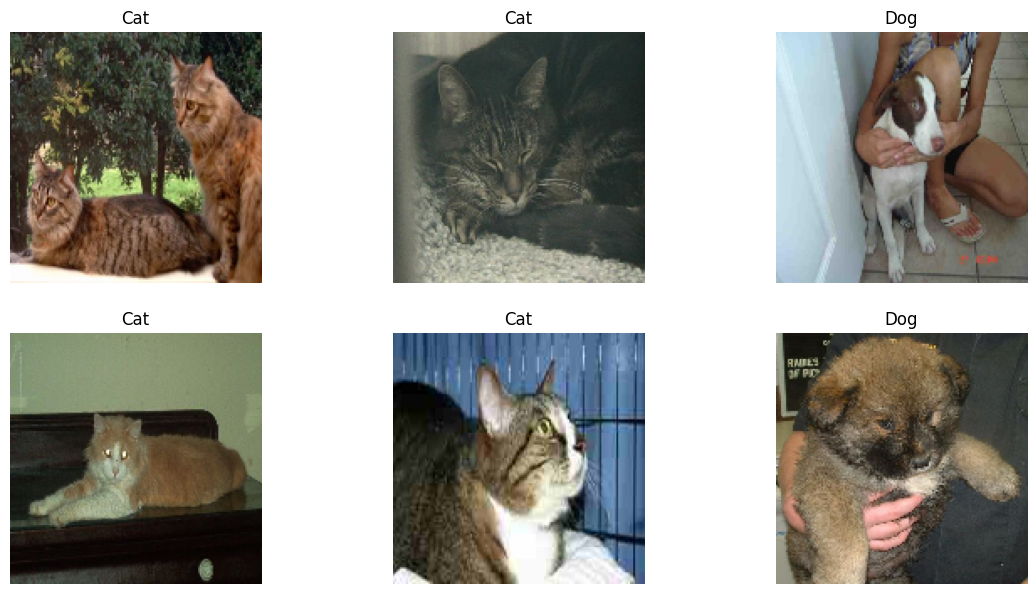

In [16]:
plot_data(train_generator, 7)

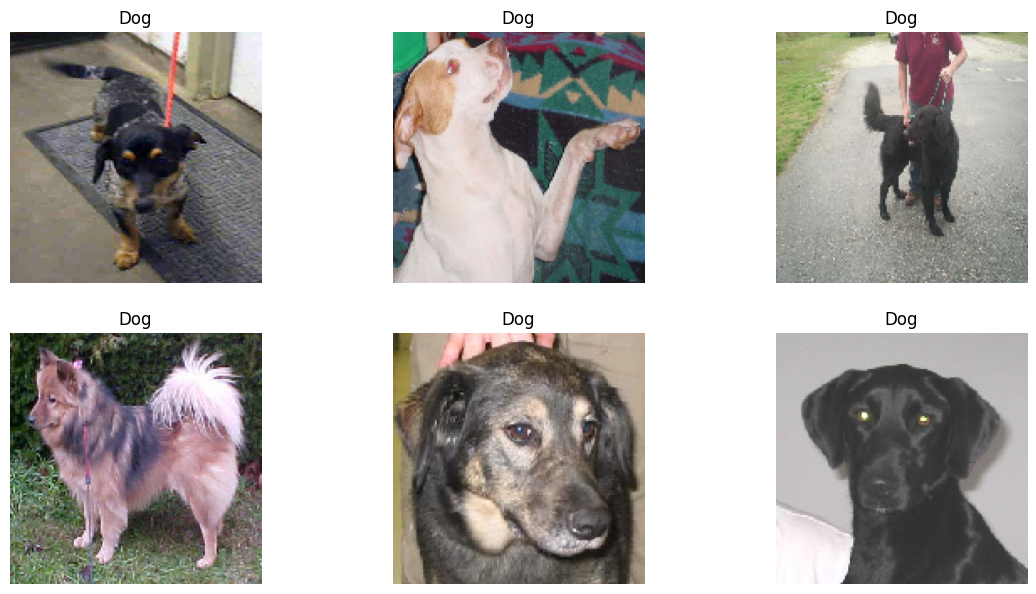

In [17]:
plot_data(validation_generator, 7)

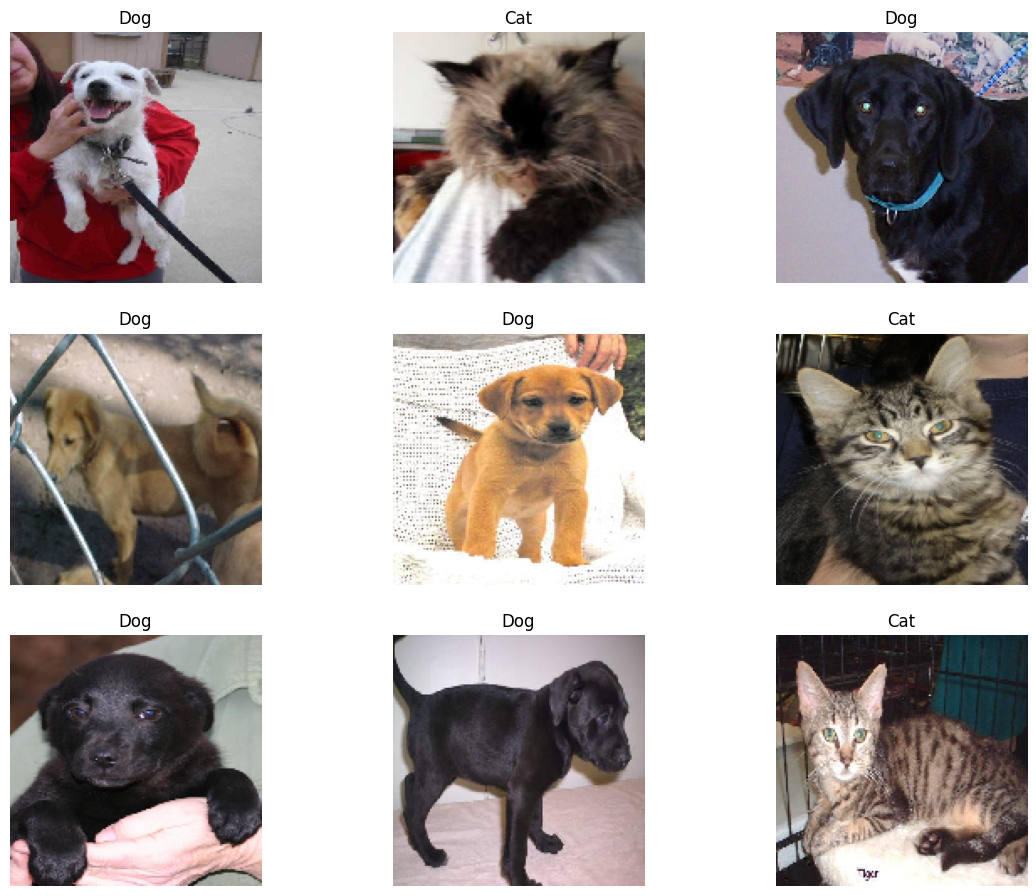

In [18]:
if INCLUDE_TEST:
  plot_data(test_generator, 10)

In [19]:
#Convolutional Neural Network
inputs = tf.keras.layers.Input(shape=(150,150,3))
x = tf.keras.layers.Conv2D(16, (3,3), activation='relu')(inputs)
x = tf.keras.layers.Conv2D(16, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(16, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(16, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(16, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(16, (3,3), activation='relu')(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = Dense(32,activation='relu')(x)
x = Dense(16,activation='relu')(x)
x = Dense(16,activation='relu')(x)
x = tf.keras.layers.Dense(2, activation='softmax')(x)

model = Model(inputs=inputs,outputs=x)

I0000 00:00:1775486163.691199    4712 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2610 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


In [20]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [21]:
r = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator)

Epoch 1/10


I0000 00:00:1775486165.699337    4712 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1775486166.620577    5247 service.cc:153] XLA service 0x756998035dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775486166.620597    5247 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1650 with Max-Q Design, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775486166.672274    5247 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775486167.010597    5247 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775486167.027983    5247 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2124__.38
E0000 00:00:1775486167.916743    5247 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing wa

  2/391 ━━━━━━━━━━━━━━━━━━━━ 32s 84ms/step - accuracy: 0.5430 - loss: 0.6928   

I0000 00:00:1775486175.579732    5247 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 35/391 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - accuracy: 0.5375 - loss: 0.6905

I0000 00:00:1775486179.747477    5247 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2124__.38
E0000 00:00:1775486182.136131    5247 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775486182.715720    5247 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


118/391 ━━━━━━━━━━━━━━━━━━━━ 35s 131ms/step - accuracy: 0.5325 - loss: 0.6910

/home/kaming/Work/data-science/.venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


391/391 ━━━━━━━━━━━━━━━━━━━━ 52s 107ms/step - accuracy: 0.5760 - loss: 0.6733 - val_accuracy: 0.6294 - val_loss: 0.6386
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.6222 - loss: 0.6401 - val_accuracy: 0.6519 - val_loss: 0.6179
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.6444 - loss: 0.6259 - val_accuracy: 0.6759 - val_loss: 0.6002
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.6778 - loss: 0.5969 - val_accuracy: 0.6967 - val_loss: 0.5691
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.7029 - loss: 0.5757 - val_accuracy: 0.7290 - val_loss: 0.5503
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.7144 - loss: 0.5615 - val_accuracy: 0.7260 - val_loss: 0.5457
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.7183 - loss: 0.5514 - val_accuracy: 0.7193 - val_loss: 0.5419
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.7284 - loss: 0.5445 - val_accura

In [22]:
if INCLUDE_TEST:
  model.evaluate(test_generator)

56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.7159 - loss: 0.5479


In [23]:
def plot_prediction(generator, n_images):
  """
  Test the modelon random predictions
  Args:
  generator: a generator
  n_images: number of images to plot
  """
  i = 1
  #Get the images and the labels from the generator
  images, labels = next(generator)
  #Gets the model predictions
  preds = model.predict(images)
  predictions = np.argmax(preds, axis=-1)
  labels = labels.astype('int32')
  plt.figure(figsize=(14, 15))
  for image, label in zip(images, labels):
    plt.subplot(4,3,i)
    plt.imshow(image)
    if predictions[i] == labels[i]:
      title_obj = plt.title(class_names[label])
      plt.setp(title_obj, color='g')
      plt.axis('off')
    else:
      title_obj = plt.title(class_names[label])
      plt.setp(title_obj, color='r')
      plt.axis('off')
    i += 1
    if i == n_images:
      break

  plt.show()



2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


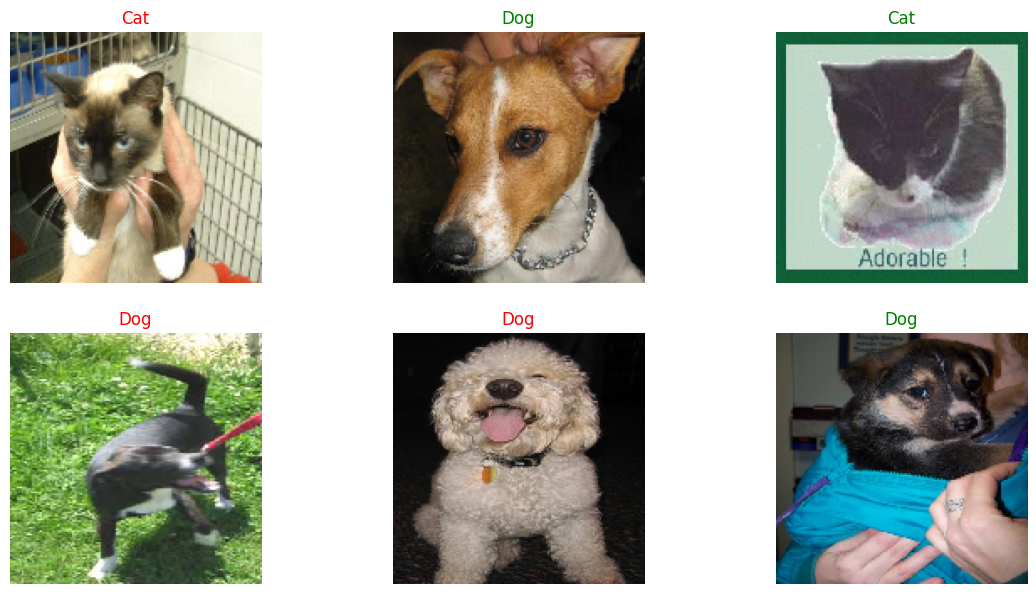

In [24]:
plot_prediction(train_generator, 7)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


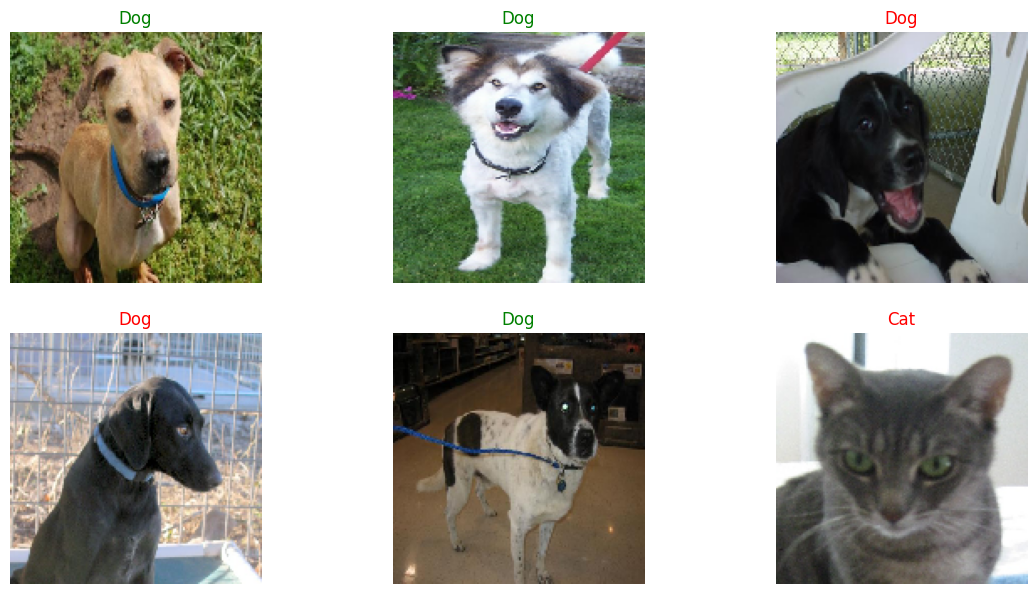

In [25]:
plot_prediction(validation_generator, 7)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


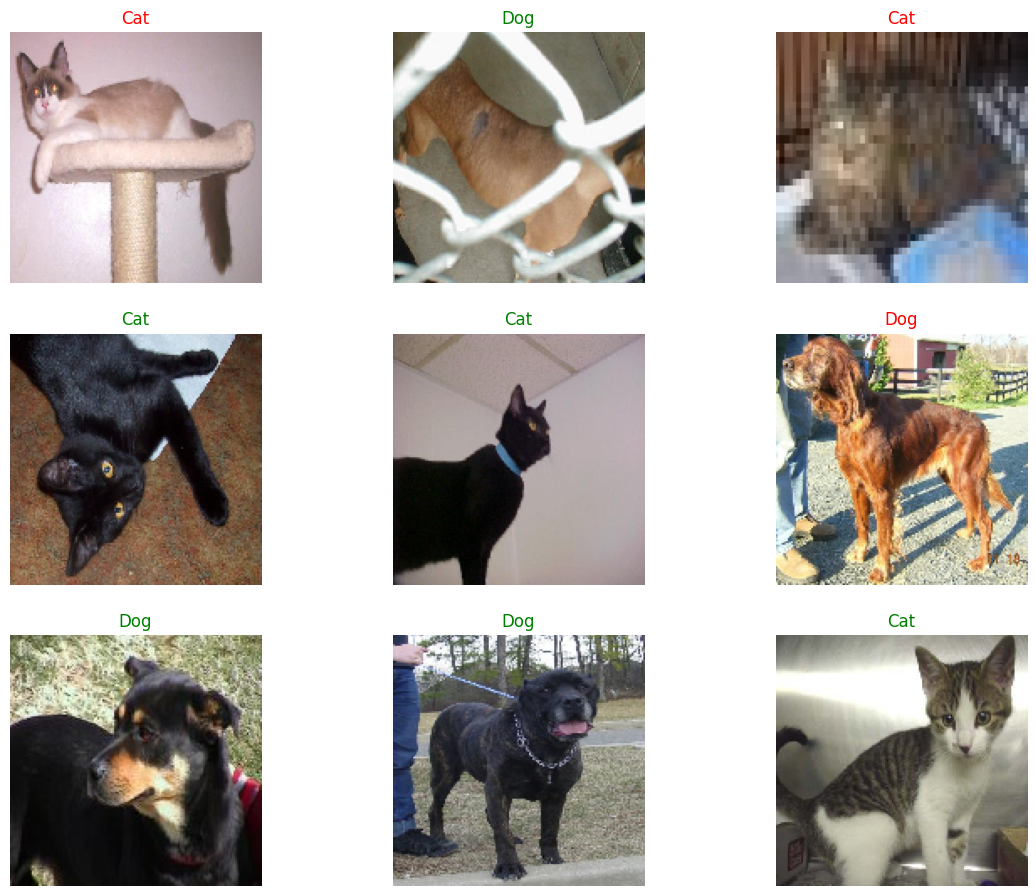

In [26]:
if INCLUDE_TEST:
    plot_prediction(test_generator, 10)

4.3 Visualize training histories

In [27]:
results = pd.DataFrame(r.history)
results.tail()

,accuracy,loss,val_accuracy,val_loss
5,0.714383,0.561527,0.725982,0.545695
6,0.718306,0.551356,0.719298,0.541866
7,0.728434,0.544502,0.732387,0.521643
8,0.736240,0.535547,0.744639,0.514327
9,0.737801,0.531885,0.736007,0.527885


In [28]:
fig = px.line(results, 
              y=[results['accuracy'], results['val_accuracy']], 
              template='seaborn', 
              color_discrete_sequence=['#1f77b4', '#ff7f0e'])
fig.update_layout(
    title_font_color='#fad25a',
    xaxis=dict(title='Epochs', color='#fad25a'), 
    yaxis=dict(color='#fad25a')
)
fig.show()

In [29]:
fig = px.line(results, 
              y=[results['loss'], results['val_loss']], 
              template='seaborn', 
              color_discrete_sequence=['#ff6b6b', '#4dabf7'])
fig.update_layout(
    title_font_color='#fad25a',
    xaxis=dict(title='Epochs', color='#fad25a'), 
    yaxis=dict(color='#fad25a')
)
fig.show()